# RFC-8 on a registered CT and MR pair

A patient has a CT and an MR, each has a segmentation, and a registration
relates them. OME-Zarr had no way to write that down, so each tool grouped
images its own way, users kept tool-specific metadata for the same
relationships, and archives published the same collection several times for
different consumers. [RFC-8](https://ngff.openmicroscopy.org/rfc/8/index.html)
addresses this.

Under RFC-8 the four pieces form one document. A segmentation names the image
it annotates instead of being stored inside it. A registration is a
transformation the document declares instead of a file beside the data. A
member can live anywhere: below, the images stay in the archive that published
them and the derived products sit on an object store.

Three constructs carry this.

A **node** is anything the format can name: an image, a label map, a group of
them. It has a type, a name and attributes.

A **path** locates a node elsewhere: `{type, path}`, where the path is relative
to the document, an absolute `file://` path or an `http(s)` URL.

A **reference** points at a node by `id`, with a `path` when the node is in
another document.

The data is one patient from the SynthRAD2025 challenge: an abdominal CT and
MR, a segmentation of each, and the deformable registration between them,
spread over three locations.


In [1]:
import io
import json
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import ngff_zarr as nz
import numpy as np
from ngff_zarr import rfc8

BASE = "https://ome-zarr-rfc8.s3.filebase.io/synthrad-1ABB070"
ARCHIVE = (
    "https://zenodo.org/api/records/15373853/files/synthRAD2025_Task1_Train.zip/content"
)
CASE = "synthRAD2025_Task1_Train/Task1/AB/1ABB070"
WORK = Path("rfc8-demo-work")
WORK.mkdir(exist_ok=True)

print("ngff-zarr", nz.__version__)

ngff-zarr 0.45.0


## The images stay where they were published

The CT and the MR are inside a 14.8 GB archive on Zenodo. Zenodo answers range
requests, so the two files come out without downloading the rest: read the
zip's central directory, then fetch each member's compressed bytes in one
request.


In [2]:
class RemoteFile(io.RawIOBase):
    """A read-only file over HTTP, backed by range requests."""

    def __init__(self, url):
        self.url, self.pos = url, 0
        request = urllib.request.Request(url, method="HEAD")
        with urllib.request.urlopen(request) as response:
            self.size = int(response.headers["Content-Length"])

    def seekable(self):
        return True

    def readable(self):
        return True

    def seek(self, offset, whence=0):
        self.pos = (offset, self.pos + offset, self.size + offset)[whence]
        return self.pos

    def tell(self):
        return self.pos

    def readinto(self, buffer):
        data = self.read(len(buffer))
        buffer[: len(data)] = data
        return len(data)

    def read(self, count=-1):
        if count is None or count < 0:
            count = self.size - self.pos
        end = min(self.pos + count, self.size) - 1
        request = urllib.request.Request(
            self.url, headers={"Range": f"bytes={self.pos}-{end}"}
        )
        with urllib.request.urlopen(request) as response:
            data = response.read()
        self.pos += len(data)
        return data


archive = zipfile.ZipFile(io.BufferedReader(RemoteFile(ARCHIVE), 1 << 20))
for name in ("ct.mha", "mr.mha"):
    target = WORK / name
    if not target.exists():
        with archive.open(f"{CASE}/{name}") as member:
            target.write_bytes(member.read())
    print(
        f"{name}: {target.stat().st_size / 1e6:.1f} MB out of {archive.fp.raw.size / 1e9:.1f} GB"
    )

ct.mha: 18.8 MB out of 14.8 GB
mr.mha: 11.0 MB out of 14.8 GB


Each image is converted to OME-Zarr with one call. At `0.9.dev3` the root
`ome` value of a store is a multiscale node; that is the change RFC-8 makes to
the core model.


In [3]:
stores = {}
for name in ("ct", "mr"):
    backend = nz.detect_cli_io_backend([str(WORK / f"{name}.mha")])
    image = nz.cli_input_to_ngff_image(backend, [str(WORK / f"{name}.mha")])
    image.name = name
    store = (WORK / f"{name}.ome.zarr").resolve()
    nz.to_ome_zarr(
        str(store),
        nz.to_multiscales(image, chunks=64),
        version="0.9.dev3",
        overwrite=True,
    )
    stores[name] = store
    print(
        f"{name}: read with {backend.value}, {image.data.shape} at "
        f"{tuple(round(v, 1) for v in image.scale.values())} mm -> {store.name}"
    )

root = json.loads((stores["ct"] / "zarr.json").read_text())["attributes"]["ome"]
print("\nthe store's own root node:", {k: root[k] for k in ("version", "type", "name")})

ct: read with itkwasm_image_io, (100, 439, 442) at (3, 1, 1) mm -> ct.ome.zarr
mr: read with itkwasm_image_io, (100, 439, 442) at (3, 1, 1) mm -> mr.ome.zarr

the store's own root node: {'version': '0.9.dev3', 'type': 'multiscale', 'name': 'ct'}


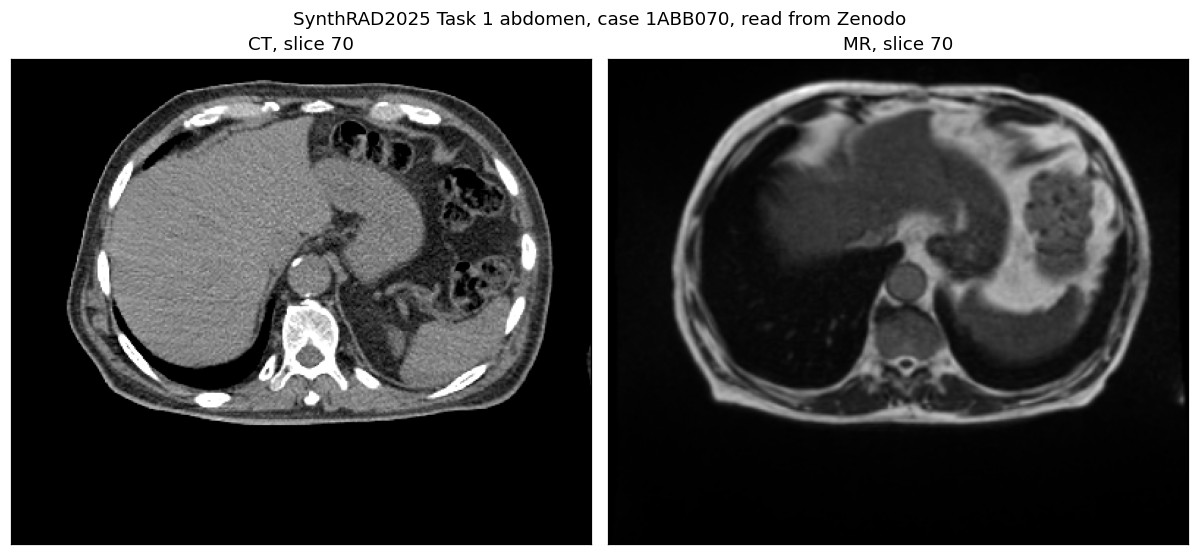

In [4]:
ct = nz.from_ome_zarr(str(stores["ct"])).images[0]
mr = nz.from_ome_zarr(str(stores["mr"])).images[0]

body = np.asarray(ct.data[ct.data.shape[0] // 2]) > -500
rows, cols = np.where(body)
crop = (slice(rows.min(), rows.max()), slice(cols.min(), cols.max()))
SLICE = 70

figure, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for axis, image, title, window in (
    (axes[0], ct, "CT", (-160, 240)),
    (axes[1], mr, "MR", (0, 600)),
):
    plane = np.asarray(image.data[SLICE])[crop]
    axis.imshow(
        np.clip((plane - window[0]) / (window[1] - window[0]), 0, 1), cmap="gray"
    )
    axis.set_title(f"{title}, slice {SLICE}")
    axis.set_xticks([])
    axis.set_yticks([])
figure.suptitle("SynthRAD2025 Task 1 abdomen, case 1ABB070, read from Zenodo")
figure.tight_layout()

## The segmentations carry their own label metadata

TotalSegmentator ran on each image through KonfAI, and the two label maps are
published on their own, apart from the images. Each is a multiscale node whose
`labels` attribute travels with it.

The attribute holds one `labelAttributes` entry per value: `labelValue`, an
RGBA `color`, and any further keys the producer adds. The v0.4 `image-label`
metadata kept the same information in two parallel lists, `colors` and
`properties`, joined on a repeated `label-value`, with nothing to keep them in
step. The structure names below come under a prefixed key, the RFC-8 form for
data an extension adds.


In [5]:
labels = {}
for side in ("ct", "mr"):
    _, document = rfc8.resolve_ome_document(
        rfc8.OmePath(
            type=rfc8.PATH_TYPE_ZARR, path=f"{BASE}/{side}-totalsegmentator.ome.zarr"
        )
    )
    node, version = rfc8.node_from_ome_dict(document["ome"])
    labels[side] = rfc8.labels(node)
    print(
        f"{side}: {node.type} node at version {version}, "
        f"{len(labels[side].labelAttributes)} label entries"
    )

for entry in labels["ct"].labelAttributes[:4]:
    print(f"  labelValue {entry.labelValue:3d}  color {entry.color}  {entry.extra}")

ct: multiscale node at version 0.9.dev3, 76 label entries
mr: multiscale node at version 0.9.dev3, 40 label entries
  labelValue   1  color [75, 121, 234, 255]  {'konfai:name': 'spleen'}
  labelValue   2  color [168, 234, 75, 255]  {'konfai:name': 'kidney_right'}
  labelValue   3  color [234, 75, 215, 255]  {'konfai:name': 'kidney_left'}
  labelValue   4  color [75, 234, 192, 255]  {'konfai:name': 'gallbladder'}


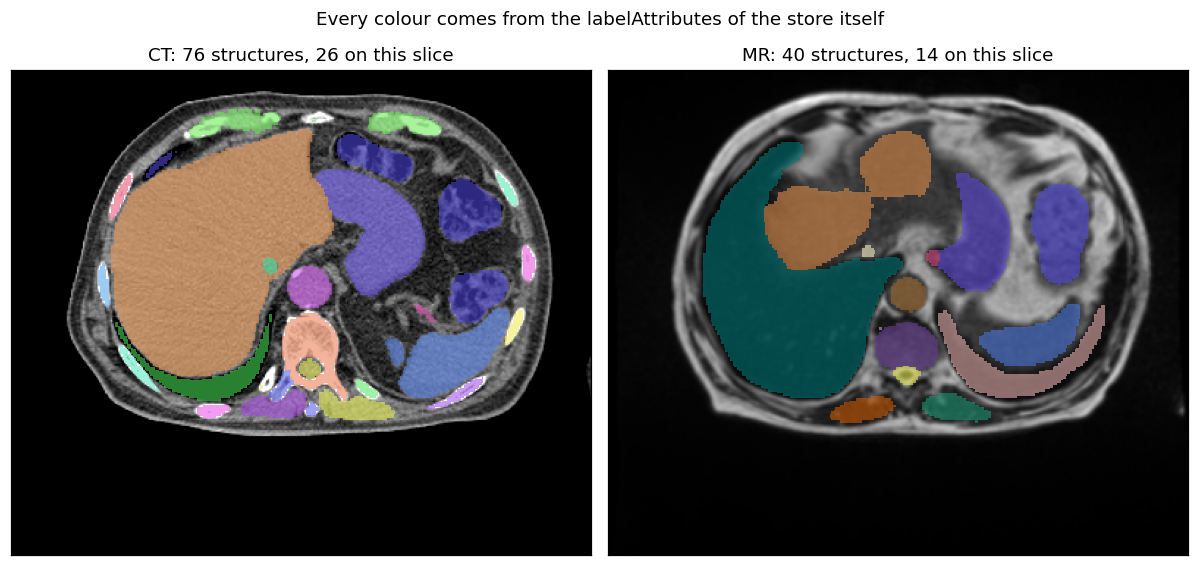

In [6]:
from matplotlib.colors import ListedColormap


def label_colormap(entries):
    """A colormap straight out of the RFC-8 label attributes."""
    size = int(max(entry.labelValue for entry in entries)) + 1
    colors = np.zeros((size, 4))
    for entry in entries:
        colors[int(entry.labelValue)] = [channel / 255 for channel in entry.color]
    colors[0] = [0, 0, 0, 0]
    return ListedColormap(colors)


segmentations = {
    side: nz.from_ome_zarr(f"{BASE}/{side}-totalsegmentator.ome.zarr").images[0]
    for side in ("ct", "mr")
}

figure, axes = plt.subplots(1, 2, figsize=(11, 5.4))
for axis, side, image, window in (
    (axes[0], "ct", ct, (-160, 240)),
    (axes[1], "mr", mr, (0, 600)),
):
    plane = np.asarray(image.data[SLICE])[crop]
    labelmap = np.asarray(segmentations[side].data[SLICE])[crop]
    colormap = label_colormap(labels[side].labelAttributes)
    axis.imshow(
        np.clip((plane - window[0]) / (window[1] - window[0]), 0, 1), cmap="gray"
    )
    axis.imshow(
        np.ma.masked_where(labelmap == 0, labelmap),
        cmap=colormap,
        vmin=0,
        vmax=colormap.N - 1,
        interpolation="nearest",
        alpha=0.55,
    )
    axis.set_title(
        f"{side.upper()}: {len(labels[side].labelAttributes)} structures, "
        f"{len(np.unique(labelmap)) - 1} on this slice"
    )
    axis.set_xticks([])
    axis.set_yticks([])
figure.suptitle("Every colour comes from the labelAttributes of the store itself")
figure.tight_layout()

Each colour is the `color` of the matching `labelValue`, read from the node on
the object store.

## One collection, three locations

The images are on the local disk, the label maps and the registration on an
object store. A collection node holds all four by their own paths, and each
label node names the image it annotates through a `source` reference.

In the v0.4 layout a segmentation belonged to an image by being stored in its
`labels/` subgroup, so the relationship was the location. With a reference the
two can live apart, a segmentation can name several sources, and several
segmentations can name one image.


In [7]:
from ngff_zarr.v06.zarr_metadata import CoordinateSystemIdentifier, Displacements


def node(node_id, name, path):
    return rfc8.Node(
        type="multiscale",
        id=node_id,
        name=name,
        path=rfc8.OmePath(type=rfc8.PATH_TYPE_ZARR, path=path),
    )


def label_node(node_id, name, store, source):
    value = node(node_id, name, f"{BASE}/{store}")
    rfc8.set_labels(value, rfc8.Labels(source=[rfc8.Reference(id=source)]))
    return value


collection = rfc8.Collection(
    id="synthrad-1ABB070",
    name="SynthRAD2025 Task 1 abdomen, case 1ABB070",
    nodes=[
        node("ct", "planning CT", stores["ct"].as_uri()),
        node("mr", "abdominal MR", stores["mr"].as_uri()),
        label_node(
            "ct-labels",
            "TotalSegmentator on the CT",
            "ct-totalsegmentator.ome.zarr",
            "ct",
        ),
        label_node(
            "mr-labels",
            "TotalSegmentator on the MR",
            "mr-totalsegmentator.ome.zarr",
            "mr",
        ),
    ],
)


def frame(store):
    """The coordinate system an image store declares for itself."""
    return CoordinateSystemIdentifier(
        id="intrinsic", path=rfc8.OmePath(type=rfc8.PATH_TYPE_ZARR, path=store)
    )


# The transformation's ends are the systems the two image stores declare,
# reached by id and path, so the registration is tied to the images by the
# metadata and not by a naming convention of this notebook.
rfc8.set_scene(
    collection,
    rfc8.Scene(
        coordinateTransformations=[
            Displacements(
                name="IMPACT B-spline, MR onto CT",
                path=f"{BASE}/mr-to-ct-displacements.ome.zarr",
                input=frame(stores["ct"].as_uri()),
                output=frame(stores["mr"].as_uri()),
            )
        ],
    ),
)

rfc8.validate_collection(collection)
for value in collection.nodes:
    source = rfc8.labels(value)
    annotates = f" annotates {source.source[0].id}" if source and source.source else ""
    where = "local" if value.path.path.startswith("file://") else "object store"
    print(f"  {value.id:10s} {where:12s} {value.name}{annotates}")

  ct         local        planning CT
  mr         local        abdominal MR
  ct-labels  object store TotalSegmentator on the CT annotates ct
  mr-labels  object store TotalSegmentator on the MR annotates mr


In [8]:
document = rfc8.to_collection_json(collection)
back, declared = rfc8.node_from_ome_dict(document["ome"])
print("declared version:", declared)
round_trip_intact = [n.id for n in back.nodes] == [n.id for n in collection.nodes]
print("round trip preserves the nodes:", round_trip_intact)
print()
print(
    json.dumps(
        {k: document["ome"][k] for k in ("version", "type", "id", "name")}, indent=1
    )
)
print("scene transformation:")
print(
    json.dumps(
        document["ome"]["attributes"]["scene"]["coordinateTransformations"][0], indent=1
    )
)

declared version: 0.9.dev3
round trip preserves the nodes: True

{
 "version": "0.9.dev3",
 "type": "collection",
 "id": "synthrad-1ABB070",
 "name": "SynthRAD2025 Task 1 abdomen, case 1ABB070"
}
scene transformation:
{
 "input": {
  "path": {
   "type": "zarr",
   "path": "file:///home/valentin/.cache/ngff-rfc8-demo/nbrun/rfc8-demo-work/ct.ome.zarr"
  },
  "id": "intrinsic"
 },
 "output": {
  "path": {
   "type": "zarr",
   "path": "file:///home/valentin/.cache/ngff-rfc8-demo/nbrun/rfc8-demo-work/mr.ome.zarr"
  },
  "id": "intrinsic"
 },
 "name": "IMPACT B-spline, MR onto CT",
 "type": "displacements",
 "path": "https://ome-zarr-rfc8.s3.filebase.io/synthrad-1ABB070/mr-to-ct-displacements.ome.zarr"
}


## Validation

The collection above validates. The documents below do not, and each error
names the rule and the location.


In [9]:
def rejected(name, mutate):
    broken = json.loads(json.dumps(document))
    mutate(broken["ome"])
    try:
        node_value, _ = rfc8.node_from_ome_dict(broken["ome"])
        rfc8.validate_collection(node_value)
    except Exception as error:
        rule = getattr(error, "rule", type(error).__name__)
        where = getattr(error, "location", "")
        print(f"{name}\n  {rule} at {where}\n  {error}\n")
    else:
        print(f"{name}: accepted, which it should not be\n")


rejected(
    "two nodes share a name",
    lambda ome: ome["nodes"][1].update(name=ome["nodes"][0]["name"]),
)
rejected(
    "an id with a space in it", lambda ome: ome["nodes"][0].update(id="planning ct")
)
rejected(
    "a source reference to an id this document does not declare",
    lambda ome: ome["nodes"][2]["attributes"]["labels"].update(
        source=[{"id": "elsewhere"}]
    ),
)
rejected(
    "a path type nothing defines",
    lambda ome: ome["nodes"][0]["path"].update(type="zip"),
)

two nodes share a name
  node-name-unique at ome.nodes[1]
  Spec rule [node-name-unique] violated: Node name 'planning CT' is repeated; node names must be unique within the enclosing collection.

an id with a space in it
  node-id-format at ome.nodes[0].id
  Spec rule [node-id-format] violated: Id 'planning ct' does not match [a-zA-Z0-9-_.]+.

a source reference to an id this document does not declare
  reference-path-required at ome.nodes[2].attributes.labels.source[0]
  Spec rule [reference-path-required] violated: Reference id 'elsewhere' is not declared in this document, so the reference must carry a 'path'.

a path type nothing defines
  path-type-known at ome.nodes[0].path.type
  Spec rule [path-type-known] violated: Path type 'zip' is not 'zarr', 'json', or a prefixed extension type.



The third case is an external reference. An `id` the document does not
declare refers to another document, and RFC-8 requires the reference to say
where that document is; without a `path` a collection could point at nothing.


## The registration

Neither label map was resampled before publication. Each is in the space it was
computed in, and the collection declares the transformation between the two.
Warping a segmentation before storing it hides the relationship in the voxels,
where it cannot be inspected, inverted or replaced.

Each end of the transformation names the coordinate system one image store
declares for itself, by id and by path. Both stores call it `intrinsic`, since
ids are scoped to a document, so the path is what tells them apart and what
ties the registration to these two images.

`nz.resample` takes the transformation from the scene. The field is a
100 x 439 x 442 x 3 store on the object store and is streamed: each output
block reads the window of the field its points fall in, then the region of the
moving image that window reaches. Neither has to fit in memory.


In [10]:
scene = rfc8.scene(collection)
transform = scene.coordinateTransformations[0]
field = nz.from_ome_zarr(transform.path)
print(
    f"{transform.type} field {field.images[0].data.shape} {field.images[0].data.dtype}"
)

ct_labels = nz.from_ome_zarr(f"{BASE}/ct-totalsegmentator.ome.zarr").images[0]
mr_labels = nz.from_ome_zarr(f"{BASE}/mr-totalsegmentator.ome.zarr").images[0]

moved = nz.resample(
    transform,
    fixed=ct_labels,
    moving=mr_labels,
    interpolator="label_image",
    fields={transform.path: field},
)
print("resampled lazily:", moved.data.shape, moved.data.dtype)

displacements field (3, 100, 439, 442) float32
resampled lazily: (100, 439, 442) uint8


Both label maps name their structures, so the organs they share can be
compared before and after the transformation.


In [11]:
names = {}
for side, value in labels.items():
    names[side] = {
        entry.extra.get("konfai:name"): int(entry.labelValue)
        for entry in value.labelAttributes
    }

CORE = [
    "liver",
    "spleen",
    "kidney_left",
    "kidney_right",
    "stomach",
    "pancreas",
    "aorta",
]
reference = np.asarray(ct_labels.data)
before = np.asarray(mr_labels.data)
after = np.asarray(moved.data)


def dice(a, b):
    total = a.sum() + b.sum()
    return 2.0 * np.logical_and(a, b).sum() / total if total else float("nan")


print(f"{'organ':14s} {'before':>7s} {'after':>7s}")
scores = []
for organ in CORE:
    target = reference == names["ct"][organ]
    if target.sum() < 500:
        continue
    b = dice(target, before == names["mr"][organ])
    a = dice(target, after == names["mr"][organ])
    scores.append((b, a))
    print(f"{organ:14s} {b:7.3f} {a:7.3f}")
print(
    f"{'mean':14s} {np.mean([s[0] for s in scores]):7.3f} {np.mean([s[1] for s in scores]):7.3f}"
)

organ           before   after
liver            0.685   0.925
spleen           0.332   0.866
kidney_left      0.594   0.861
kidney_right     0.585   0.883
stomach          0.346   0.884
pancreas         0.343   0.641
aorta            0.563   0.669
mean             0.493   0.819


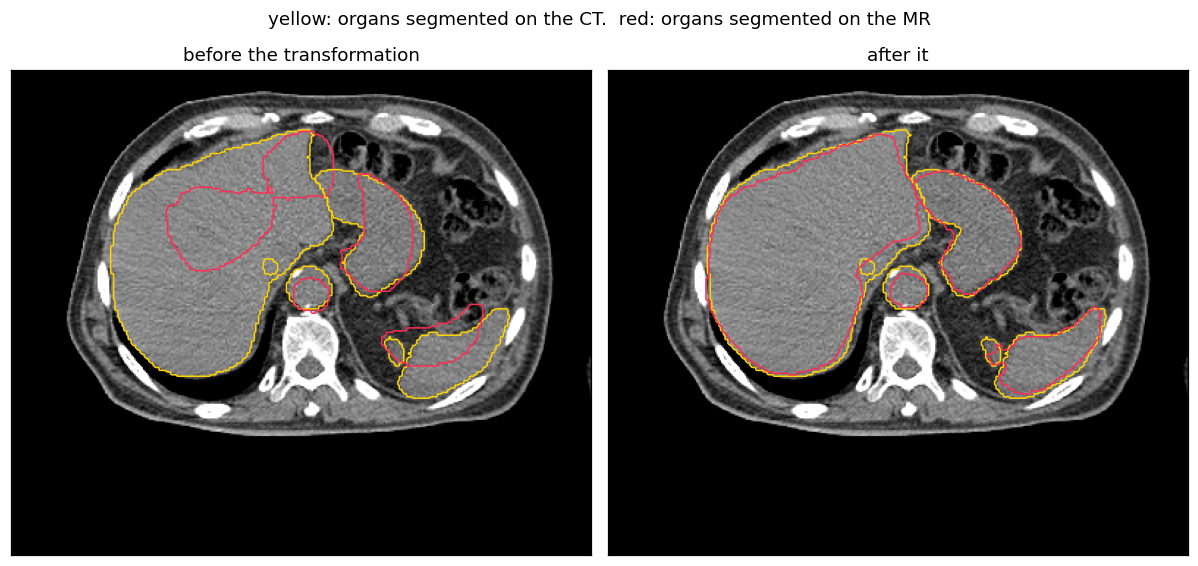

In [12]:
background = np.clip((np.asarray(ct.data[SLICE])[crop] + 160) / 400, 0, 1)

figure, axes = plt.subplots(1, 2, figsize=(11, 5.4))
for axis, labelmap, title in (
    (axes[0], before[SLICE], "before the transformation"),
    (axes[1], after[SLICE], "after it"),
):
    axis.imshow(background, cmap="gray")
    for organ in CORE:
        outline = (reference[SLICE] == names["ct"][organ])[crop]
        if outline.any():
            axis.contour(outline, levels=[0.5], colors="#ffd400", linewidths=1.0)
        moving = (labelmap == names["mr"][organ])[crop]
        if moving.any():
            axis.contour(moving, levels=[0.5], colors="#ff2d55", linewidths=1.0)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
figure.suptitle("yellow: organs segmented on the CT.  red: organs segmented on the MR")
figure.tight_layout()

## The collection document

The object store carries `collection.json` beside the three arrays it names.
Its members are relative paths, so the prefix can be moved or mirrored without
rewriting anything, and the paths resolve against wherever the document is
opened from.


In [13]:
derived = rfc8.from_collection_json(f"{BASE}/collection.json")
print("id:", derived.root.id)
print("base:", derived.base)
for value in derived.root.nodes:
    print(f"  {value.id:10s} {value.path.type:5s} {value.path.path}")

id: derived-1ABB070
base: https://ome-zarr-rfc8.s3.filebase.io/synthrad-1ABB070
  ct-labels  zarr  ./ct-totalsegmentator.ome.zarr
  mr-labels  zarr  ./mr-totalsegmentator.ome.zarr
  mr-to-ct   zarr  ./mr-to-ct-displacements.ome.zarr


A collection node holds either its nodes inline or a path to them, never both.
The study below uses the second form: the two images beside the document as
relative paths, and the derived products as one member reached by a `json`
path over the network. Nothing is fetched while the document is read.


In [14]:
study_nodes = [
    rfc8.Node(
        type="multiscale",
        id="ct",
        name="planning CT",
        path=rfc8.OmePath(type=rfc8.PATH_TYPE_ZARR, path="./ct.ome.zarr"),
    ),
    rfc8.Node(
        type="multiscale",
        id="mr",
        name="abdominal MR",
        path=rfc8.OmePath(type=rfc8.PATH_TYPE_ZARR, path="./mr.ome.zarr"),
    ),
    rfc8.Collection(
        id="derived",
        name="Segmentations and registration",
        path=rfc8.OmePath(type=rfc8.PATH_TYPE_JSON, path=f"{BASE}/collection.json"),
    ),
]
study = rfc8.Collection(id="study", name="SynthRAD2025 case 1ABB070", nodes=study_nodes)
rfc8.set_scene(study, rfc8.scene(collection))
rfc8.validate_collection(study)

rfc8.to_collection_json(study, path=str(WORK / "study.json"))
reopened = rfc8.from_collection_json(str(WORK / "study.json"))
print("opened", (WORK / "study.json").name, "with base", Path(reopened.base).name)
for value in reopened.root.nodes:
    holds = "nodes inline" if value.nodes else f"path -> {value.path.path}"
    print(f"  {value.type:11s} {value.id:8s} {holds}")

opened study.json with base rfc8-demo-work
  multiscale  ct       path -> ./ct.ome.zarr
  multiscale  mr       path -> ./mr.ome.zarr
  collection  derived  path -> https://ome-zarr-rfc8.s3.filebase.io/synthrad-1ABB070/collection.json


Following the nested member fetches the other document and returns a
collection anchored where it came from. Its members resolve from there; the
study document does not need to know about them.


In [15]:
nested = reopened.load("derived")
print(type(nested).__name__, "at", nested.base)
for value in nested.root.nodes:
    print(f"  {value.id}")

image = nested.load("ct-labels")
print(
    "\nloaded through two documents:",
    type(image).__name__,
    image.images[0].data.shape,
    image.images[0].data.dtype,
)

NgffCollection at https://ome-zarr-rfc8.s3.filebase.io/synthrad-1ABB070
  ct-labels
  mr-labels
  mr-to-ct

loaded through two documents: NgffMultiscales (100, 439, 442) uint8


A reference names a node by `id`. Inside one document that is enough, as for
the `source` references above. Pointing into another document takes a `path`
as well; the rule that refused a pathless external reference above covers this
case.


In [16]:
external = rfc8.Reference(
    id="mr-labels",
    path=rfc8.OmePath(type=rfc8.PATH_TYPE_JSON, path=f"{BASE}/collection.json"),
)
resolved = reopened.load(external)
print(
    f"reference {external.id!r} in {external.path.path.rsplit('/', 1)[-1]}"
    f" -> {type(resolved).__name__} {resolved.images[0].data.shape}"
)

reference 'mr-labels' in collection.json -> NgffMultiscales (100, 439, 442)


## Extensibility

A reader meets things it does not know. A prefixed identifier marks them at
every point the specification names: node types, attribute keys, path types,
transformation types, axis types. Unprefixed values belong to the core
specification.

`konfai:name` on a label entry is one. A whole node can be foreign in the same
way, and a reader that does not recognise the type keeps it as is.


In [17]:
study_nodes.append(
    rfc8.Node(
        type="acme:mesh",
        id="liver-surface",
        name="Liver surface mesh",
        path=rfc8.OmePath(type="acme:ply", path="./liver.ply"),
        attributes={"acme:vertices": 20344},
    )
)
extended = rfc8.Collection(id="study", name=study.name, nodes=study_nodes)
rfc8.validate_collection(extended)

document = rfc8.to_collection_json(extended)
back, _ = rfc8.node_from_ome_dict(document["ome"])
foreign = back.nodes[-1]
print(
    f"{foreign.type} node survived the round trip: {foreign.name!r},"
    f" path type {foreign.path.type}, attributes {foreign.attributes}"
)

acme:mesh node survived the round trip: 'Liver surface mesh', path type acme:ply, attributes {'acme:vertices': 20344}


## Checks

The claims above, as assertions over the computed values:


In [18]:
checks = [
    ("the root ome value is a node", root["type"] == "multiscale"),
    (
        "a node carries its own label attributes",
        len(labels["ct"].labelAttributes) == 76,
    ),
    (
        "a label map names the image it annotates",
        rfc8.labels(collection.nodes[2]).source[0].id == "ct",
    ),
    (
        "a collection holds members in two locations",
        {n.path.path.split(":")[0] for n in collection.nodes} == {"file", "https"},
    ),
    (
        "all three path forms appear",
        {"relative", "file", "https"}
        == {
            "relative"
            if not (path := value.path.path).startswith(("file:", "http"))
            else path.split(":")[0]
            for group in (collection.nodes, study.nodes, derived.root.nodes)
            for value in group
        },
    ),
    ("a document round-trips unchanged", round_trip_intact),
    (
        "a collection may hold a path instead of its nodes",
        reopened.node("derived").nodes is None,
    ),
    (
        "following it yields a collection of its own",
        type(nested).__name__ == "NgffCollection",
    ),
    (
        "a reference resolves across two documents",
        resolved.images[0].data.shape == segmentations["mr"].data.shape,
    ),
    ("an unknown node type survives", foreign.type == "acme:mesh"),
    ("the scene declares the registration", transform.type == "displacements"),
    (
        "its ends are the images' own coordinate systems",
        transform.input.id == "intrinsic"
        and transform.input.path is not None
        and transform.output.path is not None,
    ),
    (
        "applying it improves organ overlap",
        np.mean([s[1] for s in scores]) > np.mean([s[0] for s in scores]),
    ),
]
for label, ok in checks:
    print(f"  {'yes' if ok else 'NO ':3s}  {label}")
assert all(ok for _, ok in checks)

  yes  the root ome value is a node
  yes  a node carries its own label attributes
  yes  a label map names the image it annotates
  yes  a collection holds members in two locations
  yes  all three path forms appear
  yes  a document round-trips unchanged
  yes  a collection may hold a path instead of its nodes
  yes  following it yields a collection of its own
  yes  a reference resolves across two documents
  yes  an unknown node type survives
  yes  the scene declares the registration
  yes  its ends are the images' own coordinate systems
  yes  applying it improves organ overlap


## What is still open

RFC-8 is at status D1, and its text lists most of what is missing. Redundant
metadata can go out of sync, and keeping it consistent is left to
implementations. Assembling a collection costs one metadata request per node,
and a future RFC may add a consolidated form. Object store paths and a
vocabulary for relationships between nodes are listed as future possibilities.

Two gaps are not in that list.

**A reference cannot say what it expected to find.** A `Reference` is an id and
a path, a `Path` a type and a location; neither carries a checksum, a version
or a content hash. The security section covers whether a client should follow
a path, not whether what is at the end of it is still what was annotated. The
label maps above annotate an archive under someone else's control; if that
archive is replaced, they describe something else. Content addressing exists on
the storage side, and a path has no field for it.

**Converting v0.4 HCS metadata loses fields.** The draft notes that some HCS
information is not represented yet. A v0.4 acquisition carries a description, a
start time, an end time and a maximum field count; an RFC-8 acquisition carries
an id and a name, and the plate loses `field_count`. A migration drops the
provenance of when a screen was run.

A third point is a requirement on readers. The security section says an
implementation must not follow paths that escape a sandbox without the user's
consent, and should restrict which hosts it fetches from. Opening a collection
from an untrusted source with this implementation follows every path it holds,
including absolute local paths and addresses inside the local network.
Everything above was read from sources chosen in advance.


## Provenance

The CT and MR are case 1ABB070 of the SynthRAD2025 Grand Challenge training set,
Task 1, abdomen ([Zenodo](https://doi.org/10.5281/zenodo.15373853), CC BY-NC
4.0). They are read from that archive rather than republished.

> Thummerer A. et al., *SynthRAD2025 Grand Challenge Dataset: Generating
> Synthetic CTs for Radiotherapy from Head to Abdomen*, arXiv:2502.17609.

The label maps were produced by TotalSegmentator run through KonfAI
(`VBoussot/TotalSegmentator-KonfAI`, variants `total` and `total_mr`).

> Wasserthal J. et al., *TotalSegmentator: Robust Segmentation of 104 Anatomical
> Structures in CT Images*, Radiology: AI, 2023.

The displacement field is the IMPACT B-spline registration published at
`VBoussot/synthrad2025-impact-registration`, evaluated onto the CT grid and
rounded to 0.01 mm, which the 1 x 1 x 3 mm voxel resolves completely.

> Boussot V. et al., *IMPACT: A Generic Semantic Loss for Multimodal Medical
> Image Registration*, arXiv:2503.24121.
